# Random Sample Imputer

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [7]:
data = pd.read_csv('../../datasets/titanic_toy.csv')

In [8]:
data.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [9]:
data.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [11]:
x = data.drop(columns=['Survived','Family'])
y = data['Survived']

In [12]:
x.head(1)

,Age,Fare
0,22.0,7.25


In [13]:
y.head(1)

0    0
Name: Survived, dtype: int64

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [15]:
x_train.shape

(623, 2)

In [16]:
x_test.shape

(268, 2)

In [17]:
x_train['age_imputed'] = x_train['Age']
x_test['age_imputed']  = x_test['Age']

In [18]:
x_train.head(1)

,Age,Fare,age_imputed
445,4.0,81.8583,4.0


In [19]:
x_test.head(1)

,Age,Fare,age_imputed
709,NaN,15.2458,NaN


In [21]:
# Filling the null value with random values
x_train['age_imputed'][x_train['age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test['age_imputed'][x_test['age_imputed'].isnull()] = x_test['Age'].dropna().sample(x_test['Age'].isnull().sum()).values  

C:\Users\dspri\AppData\Local\Temp\ipykernel_6712\3007718713.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['age_imputed'][x_train['age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
C:

In [24]:
x_test.isnull().sum()

Age            53
Fare           15
age_imputed     0
dtype: int64

In [23]:
x_train.value_counts()

Age   Fare     age_imputed
28.0  7.8958   28.0           3
25.0  13.0000  25.0           3
34.0  13.0000  34.0           3
22.0  7.2500   22.0           3
21.0  7.9250   21.0           2
                             ..
23.0  15.0458  23.0           1
      13.7917  23.0           1
22.0  66.6000  22.0           1
      55.0000  22.0           1
80.0  30.0000  80.0           1
Name: count, Length: 434, dtype: int64

C:\Users\dspri\AppData\Local\Temp\ipykernel_6712\2814508782.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label='original',hist=False)
C:\Users\dspri\AppData\Local\Temp\ipykernel_6712\2814508782.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_test['ag

<Axes: xlabel='age_imputed', ylabel='Density'>

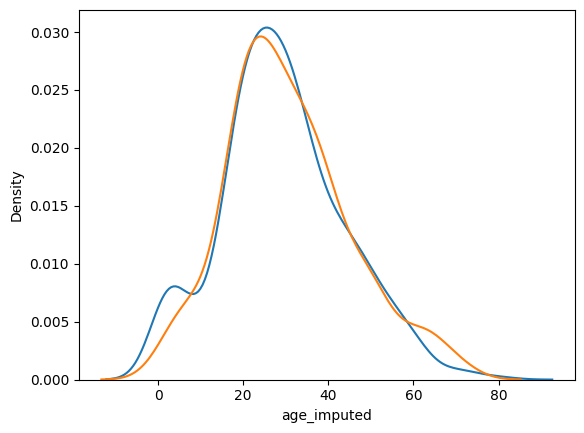

In [25]:
sns.distplot(x_train['Age'],label='original',hist=False)
sns.distplot(x_test['age_imputed'],label='original',hist=False)

In [26]:
data.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [28]:
# variance before and after imputation
print('Tha variance of age before imputation : ',x_train['Age'].var())
print('The variance of age after imputation is : ',x_test['age_imputed'].var())

Tha variance of age before imputation :  211.9518806464334
The variance of age after imputation is :  208.89129350299066


In [33]:
x_train[['Fare','Age','age_imputed']].cov()

,Fare,Age,age_imputed
Fare,2666.929672,71.822073,59.950543
Age,71.822073,211.951881,211.951881
age_imputed,59.950543,211.951881,206.559148


<Axes: >

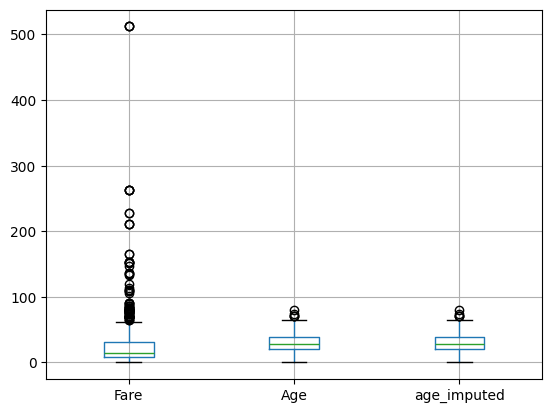

In [34]:
x_train[['Fare','Age','age_imputed']].boxplot()

# Handling random values of categorical data


In [35]:
data2 = pd.read_csv('../../datasets/train.csv')

In [37]:
data2.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [47]:
x = data2[['FireplaceQu','GarageQual']]
y = data2['SalePrice']

In [49]:
x.head(2)

,FireplaceQu,GarageQual
0,NaN,TA
1,TA,TA


In [50]:
y.head(2)

0    208500
1    181500
Name: SalePrice, dtype: int64

In [51]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [52]:
x_train['FireplaceQu_imputed'] = x_train['FireplaceQu']
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu']

x_train['GarageQual_imputed'] = x_train['GarageQual']
x_test['GarageQual_imputed'] = x_test['GarageQual']

In [53]:
x_train.head()

,FireplaceQu,GarageQual,FireplaceQu_imputed,GarageQual_imputed
135,Gd,TA,Gd,TA
1452,NaN,TA,NaN,TA
762,NaN,TA,NaN,TA
932,Gd,TA,Gd,TA
435,TA,TA,TA,TA


In [55]:
# filling null vaues

x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test['GarageQual_imputed'][x_test['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

x_train['FireplaceQu_imputed'][x_train['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test['FireplaceQu_imputed'][x_test['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

C:\Users\dspri\AppData\Local\Temp\ipykernel_6712\3802414150.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual

In [56]:
x_train.isnull().sum()

FireplaceQu            487
GarageQual              54
FireplaceQu_imputed      0
GarageQual_imputed       0
dtype: int64

In [57]:
temp = pd.concat([
    x_train['GarageQual'].value_counts()/len(x_train['GarageQual'].dropna()),
    x_train['GarageQual_imputed'].value_counts()/len(x_train),
    
],axis=1)

temp.columns = ['original','imputed']

In [58]:
temp

,original,imputed
TA,0.950413,0.948141
Fa,0.033058,0.036204
Gd,0.012397,0.011742
Ex,0.003099,0.002935
Po,0.001033,0.000978


In [59]:
temp2 = pd.concat([
    x_train['FireplaceQu'].value_counts()/len(x_train['FireplaceQu'].dropna()),
    x_train['FireplaceQu_imputed'].value_counts()/len(x_train),
    
],axis=1)

temp2.columns = ['original','imputed']

In [60]:
temp2

,original,imputed
Gd,0.487850,0.485323
TA,0.409346,0.412916
Fa,0.042991,0.041096
Ex,0.033645,0.033268
Po,0.026168,0.027397
